In [2]:
import os
import cv2
import numpy as np
import torch
import torch.utils.data
import torch.nn as nn
import yaml
import math
from tqdm import tqdm
%matplotlib notebook 


from utils.general import non_max_suppression
from utils.augmentations import mix_augmentaion
import sys
sys.path.append('/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/')

from licenceplate_deaug_pytorch.licenceplate_deaug_pytorch_aug_in_dataloader_2noise import Unet_2timeEmb, GaussianDiffusion, Trainer

In [3]:
#weight = 'static_model/best_288.pt'
#weight = 'static_model/best_726.pt'
#weight = 'static_model/last_genbg.pt'
weight = 'static_model/last_genbg_79.pt'
#weight = 'static_model/rotation.pt'



label_txt = '/data/license_plate/_plate/AOLP/label.txt'
img_dir = '/data/license_plate/_plate/AOLP/original/'


#label_txt = '/data/license_plate/_plate/weather/label.txt'
#img_dir = '/data/license_plate/_plate/weather/original/'

#abel_txt = '/data/license_plate/_plate/weather/label_with_extra.txt'
#mg_dir = '/data/license_plate/_plate/weather/original_with_extra/'

#label_txt = '/data/license_plate/_plate/weather/label_with_extra_simple.txt'
#img_dir = '/data/license_plate/_plate/weather/original_with_extra/'


#label_txt = '/data/license_plate/_plate/generated_data/result2/label.txt'
#img_dir = '/data/license_plate/_plate/generated_data/result2/img/'




data = 'data/plate.yaml'
input_size = 1024
adaptive_min = 120
conf_thres = 0.5
iou_thres = 0.5
device = 'cuda:3'
aug_licence = mix_augmentaion()

with open(data) as f:
    data = yaml.load(f, Loader=yaml.FullLoader)
classes = data['names']

self.flags_spot_light = True
self.flags_rain = True
self.flags_gamma = True
self.flags_pixelate = True


In [4]:
checkpoint = torch.load(weight)
print('Loaded {}, epoch {}'.format(weight, checkpoint['epoch']))
model = checkpoint['model'].cuda().to(device)#.half()

model.eval()
#torch.save(model.state_dict(),'runs/train/exp2/weights/rotation_state_dict.pt')
#torch.save(model.state_dict(),'static_model/rotation_state_dict.pt')
#print(model.forward_two)

Loaded static_model/last_genbg_79.pt, epoch 79


Model(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): Conv(
      (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (3): Conv(
      (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): L

In [5]:
from models.yolo_with_diffusion import Model_with_diffusion
cfgyolotiny='/data/license_plate/_yolo/yolov7/cfg/training/yolov7-tiny.yaml'
hypyolotiny='/data/license_plate/_yolo/yolov7/cfg/deploy/hyp.scratch.tiny.yaml'
#state_dict='static_model/best_288_state_dict.pt'
#state_dict='static_model/best_726_state_dict.pt'
#state_dict='static_model/last_genbg_state_dict.pt'
state_dict='static_model/last_genbg_79_state_dict.pt'
#state_dict='static_model/rotation_state_dict.pt'


nc=35
with open(hypyolotiny) as f:
    hyp = yaml.load(f, Loader=yaml.SafeLoader)  # load hyps

model = Model_with_diffusion(cfgyolotiny, ch=3, nc=nc, anchors=hyp.get('anchors')).to(device)#.half()  # create
model.load_state_dict(torch.load(state_dict))
#model.load_state_dict(torch.load(best_726_state_dict))
model.eval()
#print(model.m)


Model_with_diffusion(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): Conv(
      (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (3): Conv(
      (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)

In [6]:
work_path='/data/license_plate/Cold-Diffusion-Models/'


#model_path='/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train/model.pt'
#model_path='/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train/model_best_50000_0.513.pt'
#model_path='/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10/model.pt'
#model_path='/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10/model_best_220000_0.768.pt'
#model_path=work_path+'licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10_cityscapes/model_best_80000_0.736.pt'
#model_path=work_path+'licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10_cityscapes/model_best_130000_0.754.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10_cityscapes/'
#model_path=work_path+cityscape_path+'model_best_130000_0.754.pt'
#model_path=work_path+cityscape_path+'model_best_160000_0.761.pt'
#model_path=work_path+cityscape_path+'model_best_270000_0.766.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10_cityscapes_res/'
#model_path=work_path+cityscape_path+'model_best_60000_0.814.pt'
#model_path=work_path+cityscape_path+'model_best_150000_0.820.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train/'
#model_path=work_path+cityscape_path+'model_best_50000_0.513.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train_t100g10/'
#model_path=model_path=work_path+cityscape_path+'model_best_220000_0.768.pt'


#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_512_2loss_2noise_train_t100g10_res_cityscapes_exp/'
#model_path=model_path=work_path+cityscape_path+'model_best_150000_0.817.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7randomgen_512_2loss_2noise_train_t100g10_pnoise_cityscapes/'
#model_path=work_path+cityscape_path+'model_predice_noise_best_10000_0.613.pt'
#model_path=work_path+cityscape_path+'model_predice_noise_best_80000_0.626.pt'

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7randomgen79_512_2loss_2noise_train_t100g10_pnoise_cityscapes/'
#model_path=work_path+cityscape_path+'model_best_110000_0.721.pt'
#model_path=work_path+cityscape_path+'model_best_200000_0.729.pt'
#model_path=work_path+cityscape_path+'model_best_370000_0.736.pt'## please set residual= false and predict_noise=true
#model_path=work_path+cityscape_path+'model_best_410000_0.737.pt'
#model_path=work_path+cityscape_path+'model_best_510000_0.741.pt'##

#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7randomgen79_512_2loss_2noise_train_t100g10_pnoise/'
#model_path=work_path+cityscape_path+'model_best_640000_0.747.pt'
#model_path=work_path+cityscape_path+'model_best_690000_0.748.pt'#


# cityscape_path='licenceplate_deaug_yolov7_2noise/yolov7_512_2loss_interpolation_train/'
# model_path=work_path+cityscape_path+'model_best_470000_0.732.pt'



model_path='static_model/wo_g_model_best_390000_0.731.pt'



#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7randomgen79_512_2loss_2noise_train_t100g10_pnoise_wotemb/'
#model_path=work_path+cityscape_path+'model_best_430000_0.740.pt'##change with_time_emb to False









#clean version yolo
#cityscape_path='licenceplate_deaug_yolov7_2noise/latent_yolov7_clean_512_2loss_2noise_train_t100g10_res_cityscapes/'
#model_path=model_path=work_path+cityscape_path+'model_best_130000_0.645.pt'




#model_path='/data/license_plate/Cold-Diffusion-Models/licenceplate_deaug_yolov7_2noise/latent_yolov7_1024_2loss_2noise_train/model.pt'


data_path='/data/license_plate/_plate/generated_data/result2/img/'


diffusionmodel = Unet_2timeEmb(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels=128,
    with_time_emb=True,
    residual=False,
    predict_noise = True
).cuda().to(device)#.half()

diffusion = GaussianDiffusion(
    diffusionmodel,
    image_size = 64,
    device_of_kernel = 'cuda',
    channels = 128,
    timesteps = 100,        # number of steps
    loss_type = 'l1',                   # L1 or L2
    aug_routine='Default',
    train_routine = 'Final',
    sampling_routine = 'x0_step_down',
    yolomodel=model
).cuda().to(device)#.half()

diffusion = torch.nn.DataParallel(diffusion, device_ids=range(torch.cuda.device_count()))

diffusion_trainer = Trainer(
    diffusion,
    [data_path],
    image_size = 512,
    train_batch_size = 8,
    train_lr = 2e-5,
    train_num_steps = 700000, # total training steps
    gradient_accumulate_every = 2,      # gradient accumulation steps
    ema_decay = 0.995,                  # exponential moving average decay
    fp16 = False,                       # turn on mixed precision training with apex
    results_folder = './',
    load_path = model_path,
    dataset = 'AOLP',
    test_mode=True
)




Is Time embed used ?  True
self.flags_spot_light = True
self.flags_rain = True
self.flags_gamma = True
self.flags_pixelate = True
self.flags_spot_light = True
self.flags_rain = True
self.flags_gamma = True
self.flags_pixelate = True
(512, 512)
Loading :  static_model/wo_g_model_best_390000_0.731.pt
Step :  390000


In [7]:
def resize(img, size):
    h, w, c = img.shape
    if not (h == size and w == size):
        img = img.copy()
        scale_x = float(size / w)
        scale_y = float(size / h)
        ratio = min(scale_x, scale_y)
        nw, nh = int(w*ratio), int(h*ratio)
        new_img = cv2.resize(img, (nw, nh))

        blank = np.zeros((size, size, c))
        dw, dh = (size-nw)//2, (size-nh)//2
        blank[dh: dh+nh, dw: dw+nw] = new_img
        meta = {'nw': nw, 'nh': nh, 'dw': dw, 'dh': dh, 'w': w, 'h': h}
        return blank, meta
    else:
        meta = {}
        return img, meta

def warp_affine(pt, M):
    new_pt = np.array([pt[0], pt[1], 1.], dtype=np.float32).T
    new_pt = np.dot(M, new_pt)
    return new_pt

def affine_transform(dets, meta):
    '''
    Transfer input-sized perdictions to original-sized coordinate. (Anchor)
    Input:
        dets = [1(batch), num_objs, 6(x1, y1, x2, y2, conf, cls)]
        meta = {'nw': resize_w, 
                'nh': resize_h, 
                'dw': offset_w, 
                'dh': offset_h, 
                'w': original_size_w, 
                'h': original_size_h}
    '''
    dets = np.array([x.cpu().numpy() for x in dets[0]])
    if len(meta)>0:
        p1 = np.float32([[0, 0], [0, meta['nh']], [meta['nw'], 0]])
        p2 = np.float32([[0, 0], [0, meta['h']], [meta['w'], 0]])
        M = cv2.getAffineTransform(p1, p2)

        for i in range(dets.shape[0]):
            dets[i, 0] -= meta['dw']
            dets[i, 1] -= meta['dh']
            dets[i, 2] -= meta['dw']
            dets[i, 3] -= meta['dh']

            dets[i, 0:2] = warp_affine(dets[i, 0:2], M)
            dets[i, 2:4] = warp_affine(dets[i, 2:4], M)
        return dets
    else:
        return dets
    
    
def get_adaptive_image_size(img_path, label_data, target_min=100):
    _h=[]
    _w=[]
    
    for image_name, plate_bbox in label_data.items():
        if image_name in img_path:
            for l in plate_bbox:
                _l = l.split(',')
                x1 = int(_l[0])
                y1 = int(_l[1])
                x2 = int(_l[2])
                y2 = int(_l[3])
                h=y2-y1
                w=x2-x1
                _h.append(h)
                _w.append(w)
            _h = np.array(_h)
            _w = np.array(_w)
            min_plate_hw = np.min(np.concatenate((_h,_w),axis=0))
            adaptive_size_ratio = target_min/float(min_plate_hw)
            break
    
    return adaptive_size_ratio


def preproccess_img(img_path, adaptive_size=None):
    img = cv2.imread(img_path)
    if adaptive_size is None:
        img, meta = resize(img, input_size)
    else:
        h,w,c = img.shape
        min_hw=np.min((h,w))
        a_size = min_hw*adaptive_size
        a_size = int(a_size)
        if not a_size%64==0:
            a_size -= a_size%64
        if a_size>input_size:
            a_size=input_size
        #print(a_size)
        img, meta = resize(img, a_size)
    img = (img / 255.).astype(np.float32)
    img = img[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, to 3x512x512
    img = np.ascontiguousarray(img)
    img = torch.from_numpy(img).to(device)
    img = torch.unsqueeze(img, 0)
    #img = img.half()
    return img, meta

def run(img_path,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret = model(img)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

def run_adaptive(img_path,label_data,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    adaptive_size = get_adaptive_image_size(img_path, label_data,target_min=adaptive_min)
    img, meta = preproccess_img(img_path, adaptive_size = adaptive_size)
    with torch.no_grad():
        ret = model(img)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

def run_test_bfaf(img_path):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret1 = model(img)
        #ret1 = non_max_suppression(ret1[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)

        ret2_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        print(ret2_bf)
        ret2 = model.forward_submodel(ret2_bf,model.after_diffusion_model,init_y=y)
        #ret2 = non_max_suppression(ret2[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret1, ret2, meta

def change_yolo_detect_to_1d(_layer,batch_size):
    _layer0 = _layer[0].view(batch_size,-1)
    _layer1 = _layer[1][0].view(batch_size,-1)
    _layer2 = _layer[1][1].view(batch_size,-1)
    _layer3 = _layer[1][2].view(batch_size,-1)
    z = [_layer0,_layer1,_layer2,_layer3]
    
    output_layer = torch.cat(z,1)
    return output_layer

def run_test_pair_loss(img_path,times=99,ratio=1.0):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img_aug = aug_licence.batch_data_add_licence_aug(img, ratio)
    #loss = nn.CrossEntropyLoss()

    with torch.no_grad():
        ret1 = model(img)
        #ret1 = non_max_suppression(ret1[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)

        ret2_bf,y2 = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret2_bf.shape[0]
        y2[-1]=ret2_bf
        ret2 = model.forward_submodel(ret2_bf,model.after_diffusion_model,init_y=y2)

        ret3_bf,y3 = model.forward_submodel(img_aug,model.before_diffusion_model,output_y=True)
        batch_size = ret3_bf.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        ret_diffusion3 = diffusion_trainer.model.module.denoise_fn(ret3_bf,step)
        y3[-1]=ret_diffusion3
        ret3 = model.forward_submodel(ret_diffusion3,model.after_diffusion_model,init_y=y3)
        
            
        ret1_1d = change_yolo_detect_to_1d(ret1,batch_size)
        ret2_1d = change_yolo_detect_to_1d(ret2,batch_size)
        ret3_1d = change_yolo_detect_to_1d(ret3,batch_size)
        
        output_loss_sameimg = (ret1_1d - ret2_1d).abs().mean()
        
        output_loss_diffimg = (ret1_1d - ret3_1d).abs().mean()

        print(output_loss_sameimg)
        print(output_loss_diffimg)
        #ret2 = non_max_suppression(ret2[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)

def run_withdiffusion(img_path,times=99, step_t=None, step_g=None,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    if step_t is None:
        step_t=times - 1
    if step_g is None:
        step_g=times - 1
        
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret_bf.shape[0]
        step_t = torch.full((batch_size,), step_t, dtype=torch.long).cuda().to(device)#.half()
        step_g = torch.full((batch_size,), step_g, dtype=torch.long).cuda().to(device)#.half()
        
        ret_diffusion = diffusion_trainer.model.module.denoise_fn(ret_bf,step_t,step_g)
        
        #print('ret_bf = '+str(torch.mean(ret_bf))+str(torch.min(ret_bf))+str(torch.max(ret_bf)))
        #print('ret_diffusion = '+str(torch.mean(ret_diffusion))+str(torch.min(ret_diffusion))+str(torch.max(ret_diffusion)))

        #ret_diffusion = ret_bf
        y[-1]=ret_diffusion
        ret = model.forward_submodel(ret_diffusion,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

def run_withdiffusion_adaptive(img_path,label_data,times=99, step_t=None, step_g=None,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    adaptive_size = get_adaptive_image_size(img_path, label_data,target_min=adaptive_min)
    img, meta = preproccess_img(img_path, adaptive_size = adaptive_size)
    if step_t is None:
        step_t=times - 1
    if step_g is None:
        step_g=times - 1
        
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret_bf.shape[0]
        step_t = torch.full((batch_size,), step_t, dtype=torch.long).cuda().to(device)#.half()
        step_g = torch.full((batch_size,), step_g, dtype=torch.long).cuda().to(device)#.half()
        
        ret_diffusion = diffusion_trainer.model.module.denoise_fn(ret_bf,step_t,step_g)
        
        #print('ret_bf = '+str(torch.mean(ret_bf))+str(torch.min(ret_bf))+str(torch.max(ret_bf)))
        #print('ret_diffusion = '+str(torch.mean(ret_diffusion))+str(torch.min(ret_diffusion))+str(torch.max(ret_diffusion)))

        #ret_diffusion = ret_bf
        y[-1]=ret_diffusion
        ret = model.forward_submodel(ret_diffusion,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta



def run_withdiffusion_eval(img_path,times=99,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret_bf.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        
        ret_diffusion = diffusion_trainer.model.module.denoise_fn(ret_bf,step)
        
        #print('ret_bf = '+str(torch.mean(ret_bf))+str(torch.min(ret_bf))+str(torch.max(ret_bf)))
        #print('ret_diffusion = '+str(torch.mean(ret_diffusion))+str(torch.min(ret_diffusion))+str(torch.max(ret_diffusion)))

        #ret_diffusion = ret_bf
        y[-1]=ret_diffusion
        ret = model.forward_submodel(ret_diffusion,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta


def run_wodiffusion(img_path,times=99,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        y[-1]=ret_bf
        ret = model.forward_submodel(ret_bf,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta


def run_withdiffusion_ema(img_path,times=100):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret_bf.shape[0]
        step = torch.full((batch_size,), times - 1, dtype=torch.long).cuda().to(device)#.half()
        
        ret_diffusion = diffusion_trainer.ema_model.module.denoise_fn(ret_bf,step)
        
        #print('ret_bf = '+str(torch.mean(ret_bf))+str(torch.min(ret_bf))+str(torch.max(ret_bf)))
        #print('ret_diffusion = '+str(torch.mean(ret_diffusion))+str(torch.min(ret_diffusion))+str(torch.max(ret_diffusion)))

        #ret_diffusion = ret_bf
        y[-1]=ret_diffusion
        ret = model.forward_submodel(ret_diffusion,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta



def run_aug_withdiffusion(img_path,times=99, step_t=None, step_g=None,conf_thres=conf_thres):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    img = aug_licence.batch_data_add_licence_aug(img, ratio)

    if step_t is None:
        step_t=times - 1
    if step_g is None:
        step_g=times - 1
        
    with torch.no_grad():
        ret_bf,y = model.forward_submodel(img,model.before_diffusion_model,output_y=True)
        batch_size = ret_bf.shape[0]
        step_t = torch.full((batch_size,), step_t, dtype=torch.long).cuda().to(device)#.half()
        step_g = torch.full((batch_size,), step_g, dtype=torch.long).cuda().to(device)#.half()
        
        ret_diffusion = diffusion_trainer.model.module.denoise_fn(ret_bf,step_t,step_g)
        
        #print('ret_bf = '+str(torch.mean(ret_bf))+str(torch.min(ret_bf))+str(torch.max(ret_bf)))
        #print('ret_diffusion = '+str(torch.mean(ret_diffusion))+str(torch.min(ret_diffusion))+str(torch.max(ret_diffusion)))

        #ret_diffusion = ret_bf
        y[-1]=ret_diffusion
        ret = model.forward_submodel(ret_diffusion,model.after_diffusion_model,init_y=y)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta



def run_aug(img_path,ratio=1.0):
    '''
    Return: output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
    '''
    img, meta = preproccess_img(img_path)
    b, c, h, w = img.shape
    aug_licence.imshape=[h,w]
    aug_licence.random_parameter()

    img = aug_licence.batch_data_add_licence_aug(img, ratio)
    with torch.no_grad():
        ret = model(img)
        ret = non_max_suppression(ret[0], conf_thres=conf_thres, iou_thres=iou_thres, labels=[], multi_label=True)
    return ret, meta

#==================================================================

def transfer_label(lab):
    '''
    Transfer label(string) into list(int).
    Input:
        lab: string list ['x_min,y_min,x_max,y_max,plate']
            i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        new_lab: int list [x_min, y_min, x_max, y_max]
            i.e. [[14,71,83,105], [215,188,324,240]]
    '''
    new_lab = []
    for l in lab:
        _l = l.split(',')
        x1 = int(_l[0])
        y1 = int(_l[1])
        x2 = int(_l[2])
        y2 = int(_l[3])
        new_lab.append([x1, y1, x2, y2])
    
    return new_lab

def get_iou(bb1, bb2):
    '''
    Input:
        bb1(groundtruth) = [left_top_x, y, right_bottom_x, y]
        bb2(predict_point) = [left_top_x, y, right_bottom_x, y]
    '''
    x_left = max(bb1[0], bb2[0])
    y_top = max(bb1[1], bb2[1])
    x_right = min(bb1[2], bb2[2])
    y_bottom = min(bb1[3], bb2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)

    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])

    iou = intersection_area / float(bb1_area + bb2_area - intersection_area)
    assert iou >= 0.0
    assert iou <= 1.0
    return iou

def check_bbox_old(bb1, bb2):
    '''
    Check if bb2 is completely covered by bb1.
    If so, return True, otherwise return False.
    Input:
        bb1(large region) = [x_min, y_min, x_max, y_max] (all int)
        bb2(small region) = [x_min, y_min, x_max, y_max] (all int)
    '''
    # Assert bb1 is the larger one
    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])
    if bb1_area < bb2_area:
        temp = bb2
        bb2 = bb1
        bb1 = temp
    
    f1 = bb1[0] <= bb2[0]
    f2 = bb1[1] <= bb2[1]
    f3 = bb1[2] >= bb2[2]
    f4 = bb1[3] >= bb2[3]

    if f1 and f2 and f3 and f4:
        return True
    else:
        return False
    
def check_bbox(bb1, bb2):
    '''
    Check if the center point of bb2 is within bb1.
    If so, return True, otherwise return False.
    Input:
        bb1(large region) = [x_min, y_min, x_max, y_max] (all int)
        bb2(small region) = [x_min, y_min, x_max, y_max] (all int)
    '''
    # Assert bb1 is the larger one
    bb1_area = (bb1[2] - bb1[0]) * (bb1[3] - bb1[1])
    bb2_area = (bb2[2] - bb2[0]) * (bb2[3] - bb2[1])
    if bb1_area < bb2_area:
        temp = bb2
        bb2 = bb1
        bb1 = temp
        
    b2cx = (bb2[0] + bb2[2]) / 2
    b2cy = (bb2[1] + bb2[3]) / 2
    
    f1 = (bb1[0] < b2cx < bb1[2])
    f2 = (bb1[1] < b2cy < bb1[3])
    if f1 and f2:
        return True
    else:
        return False
    
#     f1 = bb1[0] <= bb2[0]
#     f2 = bb1[1] <= bb2[1]
#     f3 = bb1[2] >= bb2[2]
#     f4 = bb1[3] >= bb2[3]

#     if f1 and f2 and f3 and f4:
#         return True
#     else:
#         return False


def group_plate(outp):
    '''
    Group each character into seperate plates.
    Input:
        outp = float[[x1, y1, x2, y2, score, class], ...]
            i.e. [[     40.859      162.66      142.42      216.09      0.9668          34]
                  [     125.08      178.28      138.83      208.91     0.93213           6]
                  [         95      176.41      110.94      207.03      0.9248           8]
                  [     110.16      177.34      125.16      208.28     0.91211           8]
                  [     80.156      175.47      97.344      206.72     0.90674           4]
                  [     45.039      173.44      64.414         205     0.89111          13]
                  [     60.078      174.06      78.828      205.62     0.81445          17]]
    Return: 
        a sorted list of dict [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, idx], ...]}, ...]
             i.e. [{'plate': [40, 162, 142, 216], 
                    'char':  [[45, 173, 64, 205, 13],
                             [60, 174, 78, 205, 17],
                             [80, 175, 97, 206, 4],
                             [95, 176, 110, 207, 8],
                             [110, 177, 125, 208, 8],
                             [125, 178, 138, 208, 6]]}]
    '''
    plates = []
    chars = []
    groups = []
    for obj in outp:
        if int(obj[-1]) == 34:
            pla = [int(p) for p in obj[:4]]
            group = {'plate': pla, 'char':[]}
            groups.append(group)
        else:
            chars.append(obj)
    for obj in chars:
        cha = [int(obj[0]), int(obj[1]), int(obj[2]), int(obj[3]), int(obj[5])]
        for g in groups:
            pla = g['plate']
            if check_bbox(pla, cha[:4]):
                g['char'].append(cha)
    ### Sort list
    for g in groups:
        g['char'] = sorted(g['char'], key=lambda x: x[0])
    return groups

def get_str(chars):
    '''
    Create plate string from indivisual detected character.
    Input:
        chars = a sorted list [int[x1, y1, x2, y2, idx], ...]]
    Return:
        plate_str = plate string, i.e. 'DH4886'
    '''
    s = ''
    for o in chars:
        c = o[-1]
        s += classes[c]
    return s

def get_acc(inp, outp):
    """
    Compute two strings character by character.
    Input:
        inp: ground truth(str)
        outp: detected result(str)
    Return:
        m: number of groundtruth(int)
        count: number of detect correctly(int)
    """
    m = len(inp)
    count = sum((Counter(inp) & Counter(outp)).values())
    return m, count

def compute_acc(outp, labels):
    '''
    Compute accuracy between detected results and labels.
    Input:
        outp = a list of dic [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, idx], ...]}, ...]
        labels = a list of str, i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        total = the number of all characters in labels
        correct = the number of correct-detected characters
    '''
    total = 0
    correct = 0
    for label in labels:
        line = label.split(',')
        plate_gt = [int(x) for x in line[:4]]
        for g in outp:
            if get_iou(plate_gt, g['plate']) >= 0.5:
                detected_plate = get_str(g['char'])
                t, c = get_acc(line[-1], detected_plate)
                total += t
                correct += c
    return total, correct

def labels_len(labels):
    '''
    Compute the number of characters in ground truth.
    Input:
        labels = a list of str, i.e. ['14,71,83,105,FS799', '215,188,324,240,DP4846']
    Return:
        num = the number of characters of all plates
    '''
    num = 0
    for label in labels:
        lines = label.split(',')
        n = len(lines[-1])
        num += n
    return num

def get_wer(r, h):
    """
    Compute word_error_rate(WER) of two list of strings.
    Input:
        r = ground truth
        h = predicted results
    Return:
        result = WER (presented in percentage)
        sid = substitution + insertion + deletion
        total = the number of groundtruth
    """
    d = np.zeros((len(r) + 1) * (len(h) + 1), dtype=np.uint16)
    d = d.reshape((len(r) + 1, len(h) + 1))
    for i in range(len(r) + 1):
        for j in range(len(h) + 1):
            if i == 0:
                d[0][j] = j
            elif j == 0:
                d[i][0] = i

    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            if r[i - 1] == h[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                substitution = d[i - 1][j - 1] + 1
                insertion = d[i][j - 1] + 1
                deletion = d[i - 1][j] + 1
                d[i][j] = min(substitution, insertion, deletion)
    sid = d[len(r)][len(h)]
    total = len(r)
    result = float(sid) / total * 100

    return result, sid, total

def view_dataset(label_data):
    correct_plate = {}
    total_p, correct_p, pred_p = 0, 0, 0
    H=[]
    W=[]
    for k, v in label_data.items():
        print(k)
        print(v)
        gt = transfer_label(v)
        for bbox in gt:
            h=bbox[2]-bbox[0]
            w=bbox[3]-bbox[1]
            H.append(h)
            W.append(w)
    return H,W

def fliter_by_length(data):
    after_filter = []
    for x in data:
        if len(x['char'])>=2 and len(x['char'])<=7:
            after_filter.append(x)
    return after_filter

def eval_dataset(results,label_data,word_length_filter=False):
    correct_plate = {}
    total_p, correct_p, pred_p = 0, 0, 0
    for k, v in label_data.items():
        gt = transfer_label(v)
        total_p += len(gt)
        if k in results:
            r = group_plate(results[k]) # r = [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, label], ...]}, ...]
            if word_length_filter:
                r = fliter_by_length(r)
            pred_p += len(r)
            correct_r = []
            for _r in r:
                for idx, bbox in enumerate(gt):
                    if get_iou(bbox, _r['plate']) >= 0.5:
                        n_r = {'plate': _r['plate'], 'char': _r['char'], 'idx': idx}
                        correct_r.append(n_r)
            num = len(correct_r)
            if num > 0:
                correct_plate[k] = correct_r
                correct_p += num
    if not pred_p ==0:

        print("Number of Correctly Detected Plates =", correct_p)
        print("Number of Detected Plates =", pred_p)
        print("Number of All Plates =", total_p)
        print("Recall = {:.4f}".format(correct_p/total_p))
        print("Precision = {:.4f}".format(correct_p/pred_p))

        n_perfect = 0  ### number of perfectly recognized plates
        n_sid = 0  ### number of failed recognized chars in detected
        n_detected = 0  ### number of chars in detected plates
        filterout_gt = 0

        for k, v in label_data.items():
            gt_strs = [s.split(',')[-1] for s in v]
            for gt_str in gt_strs:
                if len(gt_str)<5 or len(gt_str)>7:
                    filterout_gt+=1
                    #print(gt_str)
            if k in correct_plate:
                objs = correct_plate[k]
                for obj in objs: # obj = [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, label], ...], 'idx': int(i)}]
                    pred_str = [classes[x[-1]] for x in obj['char']]
                    wer, sid, t = get_wer(list(gt_strs[obj['idx']]), pred_str)
                    n_sid += sid
                    n_detected += t
                    if wer == 0:
                        n_perfect += 1

        print("Filter out ground truth = ", filterout_gt)
        print("Characters in Detected Plates = ", n_detected)
        print("Error Characters (Detected) =", n_sid)
        print("World Error Rate (Detected) = {:.4f}".format(n_sid/n_detected))

        print("\nNumber of Perfectly Recognized Plates = ", n_perfect)
        print("Accuracy(Detected) = {:.4f}".format(n_perfect/correct_p))
        print("Accuracy(Groundtruth) = {:.4f}".format(n_perfect/total_p))

In [8]:
"""
Create label dictionary.
Format: dic = {key: file_name(str), value: [obj1(str), obj2(str), ...]}
        obj format = 'x_min, y_min, x_max, y_max, plate'
   i.e. dic['train_LE_3'] = ['266,199,350,242,2972KK']
        dic['train_LE_33'] = ['14,71,83,105,FS799', '215,188,324,240,DP4846']
"""
label_data = {}
#label_txt = '/data/license_plate/_plate/AOLP/label.txt'
#label_txt = '/data/license_plate/_plate/weather/label.txt'
#label_txt = '/data/license_plate/_plate/weather/label_with_extra.txt'
#label_txt = '/data/license_plate/_plate/weather/label_crop.txt'
#label_txt = '/data/license_plate/_plate/weather/label_crop_with_extra.txt'
#label_txt = '/data/license_plate/_plate/generated_data/result2/label.txt'
label_file = open(label_txt, 'r')
lines = label_file.readlines()
for line in lines:
    l = line.strip().split(' ')
    name = l[0]
    plates = l[1:]
    label_data[name] = plates

In [9]:
#img_dir = '/data/license_plate/_plate/AOLP/original/'
#img_dir = '/data/license_plate/_plate/weather/original/'
#img_dir = '/data/license_plate/_plate/weather/original_with_extra/'
#img_dir = '/data/license_plate/_plate/weather/crop/'
#img_dir = '/data/license_plate/_plate/weather/crop_with_extra/'



#img_dir = '/data/license_plate/_plate/generated_data/result2/img_blur/'
#img_dir = '/data/license_plate/_plate/generated_data/result2/img/'

img_paths = os.listdir(img_dir)
img_paths.sort()
model.create_subnetwork()
#model.before_diffusion_model.half()
#model.after_diffusion_model.half()

In [11]:

param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('yolov7-tiny model size: {:.3f}MB'.format(size_all_mb))


yolov7-tiny model size: 23.353MB


In [10]:
d_model=diffusion_trainer.model
param_size = 0
for param in d_model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in d_model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('diffusion model size: {:.3f}MB'.format(size_all_mb))


diffusion model size: 241.308MB


In [11]:
# test original network and after clip subnet should be all same(mean=max=min=0)
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'

results = {}
for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret1, ret2, meta = run_test_bfaf(img_p)
        #print(ret1[1][0])
        #print(ret2[1][0])
        for idx_ret in range(len(ret1)):
            print(str(idx_ret)+'_'+str(torch.mean(ret1[idx_ret][0]-ret2[idx_ret][0]))+str(torch.min(ret1[idx_ret][0]-ret2[idx_ret][0]))+str(torch.max(ret1[idx_ret][0]-ret2[idx_ret][0])))
        break

  0%|                                                    | 0/47 [00:00<?, ?it/s]


NameError: name 'run_test_bfaf' is not defined

## yolov7 results

In [10]:
# img_dir = 'E:/MTL_FTP/ChengJungC/dataset/AOLP/original/'
#img_dir = 'E:/MTL_FTP/ChengJungC/dataset/weather/original/'

results = {}
print('conf_thres= '+str(conf_thres))

for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p,conf_thres=conf_thres)
        #print(conf_thres)
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
eval_dataset(results,label_data)

  0%|                                                  | 0/2049 [00:00<?, ?it/s]

conf_thres= 0.5


100%|███████████████████████████████████████| 2049/2049 [01:42<00:00, 20.07it/s]


Number of Correctly Detected Plates = 2154
Number of Detected Plates = 3046
Number of All Plates = 2164
Recall = 0.9954
Precision = 0.7072
Filter out ground truth =  24
Characters in Detected Plates =  12857
Error Characters (Detected) = 423
World Error Rate (Detected) = 0.0329

Number of Perfectly Recognized Plates =  1854
Accuracy(Detected) = 0.8607
Accuracy(Groundtruth) = 0.8567


In [11]:
eval_dataset(results,label_data,word_length_filter=True)

Number of Correctly Detected Plates = 2130
Number of Detected Plates = 2342
Number of All Plates = 2164
Recall = 0.9843
Precision = 0.9095
Filter out ground truth =  24
Characters in Detected Plates =  12715
Error Characters (Detected) = 341
World Error Rate (Detected) = 0.0268

Number of Perfectly Recognized Plates =  1854
Accuracy(Detected) = 0.8704
Accuracy(Groundtruth) = 0.8567


In [9]:
results = {}
print('conf_thres= '+str(conf_thres))

for f in tqdm(img_paths, ncols=80):
    if f.endswith('.jpg'):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p,conf_thres=conf_thres)
        #print(conf_thres)
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
eval_dataset(results,label_data)

  0%|                                                 | 0/10000 [00:00<?, ?it/s]

conf_thres= 0.5


100%|█████████████████████████████████████| 10000/10000 [05:27<00:00, 30.56it/s]


Number of Correctly Detected Plates = 19935
Number of Detected Plates = 19944
Number of All Plates = 19940
Recall = 0.9997
Precision = 0.9995
Characters in Detected Plates =  119588
Error Characters (Detected) = 1242
World Error Rate (Detected) = 0.0104

Number of Perfectly Recognized Plates =  19107
Accuracy(Detected) = 0.9585
Accuracy(Groundtruth) = 0.9582


## diffusion step=99

In [12]:
print('conf_thres= '+str(0.5))
_t=[]
_g=[]
results_all=[]


results = {}
print('conf_thres= '+str(conf_thres))

for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p,conf_thres=conf_thres)
        #ret, meta = run_adaptive(img_p,label_data,conf_thres=conf_thres)
        #print(conf_thres)
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
            
_t.append(-1)
_g.append(-1)
results_all.append(results)

            
for step_g in [0,10]:
    for step_t in [0,25,50,75,100]:
#for step_g in [0]:
#    for step_t in [50]:
        results_diffusion = {}
        for f in tqdm(img_paths, ncols=80):
            if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
                bname = os.path.splitext(f)[0]
                img_p = img_dir + f
                
                ret, meta = run_withdiffusion(img_p,label_data,step_t=step_t,step_g=step_g,conf_thres=0.5)
                #ret, meta = run_withdiffusion_adaptive(img_p,label_data,step_t=step_t,step_g=step_g,conf_thres=0.5)

                if ret[0] is not None:
                    output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
                    results_diffusion[bname] = output
        _t.append(step_t)
        _g.append(step_g)
        results_all.append(results_diffusion)
            
#eval_dataset(results_diffusion,label_data)

  0%|                                          | 3/2049 [00:00<01:37, 20.99it/s]

conf_thres= 0.5
conf_thres= 0.5


100%|███████████████████████████████████████| 2049/2049 [02:27<00:00, 13.88it/s]


In [13]:
word_length_filter=True


print('model_path= %s'%(model_path))
print('input_size= %s'%(input_size))
print('label_txt= %s'%(label_txt))
print('img_dir= %s'%(img_dir))
print('word_length_filter = '+str(word_length_filter))

#print('adaptive_min= %s'%(adaptive_min))
#print('model_path= %s'%(model_path))

for _ind,result_ in enumerate(results_all):
    now_t=_t[_ind]
    now_g=_g[_ind]
    print('--------------')
    print('step_t = %d, step_g = %d'%(now_t,now_g))
    eval_dataset(result_,label_data,word_length_filter=word_length_filter)
    #eval_dataset(result_,label_data)

model_path= static_model/wo_g_model_best_390000_0.731.pt
input_size= 1024
label_txt= /data/license_plate/_plate/AOLP/label.txt
img_dir= /data/license_plate/_plate/AOLP/original/
word_length_filter = True
--------------
step_t = -1, step_g = -1
Number of Correctly Detected Plates = 2130
Number of Detected Plates = 2342
Number of All Plates = 2164
Recall = 0.9843
Precision = 0.9095
Filter out ground truth =  24
Characters in Detected Plates =  12715
Error Characters (Detected) = 341
World Error Rate (Detected) = 0.0268

Number of Perfectly Recognized Plates =  1854
Accuracy(Detected) = 0.8704
Accuracy(Groundtruth) = 0.8567
--------------
step_t = 0, step_g = 0
Number of Correctly Detected Plates = 2130
Number of Detected Plates = 2329
Number of All Plates = 2164
Recall = 0.9843
Precision = 0.9146
Filter out ground truth =  24
Characters in Detected Plates =  12715
Error Characters (Detected) = 341
World Error Rate (Detected) = 0.0268

Number of Perfectly Recognized Plates =  1854
Accurac

# WLP

In [16]:
label_txt = '/data/license_plate/_plate/weather/label.txt'
img_dir = '/data/license_plate/_plate/weather/original/'
input_size = 2048

"""
Create label dictionary.
Format: dic = {key: file_name(str), value: [obj1(str), obj2(str), ...]}
        obj format = 'x_min, y_min, x_max, y_max, plate'
   i.e. dic['train_LE_3'] = ['266,199,350,242,2972KK']
        dic['train_LE_33'] = ['14,71,83,105,FS799', '215,188,324,240,DP4846']
"""
label_data = {}
#label_txt = '/data/license_plate/_plate/AOLP/label.txt'
#label_txt = '/data/license_plate/_plate/weather/label.txt'
#label_txt = '/data/license_plate/_plate/weather/label_with_extra.txt'
#label_txt = '/data/license_plate/_plate/weather/label_crop.txt'
#label_txt = '/data/license_plate/_plate/weather/label_crop_with_extra.txt'
#label_txt = '/data/license_plate/_plate/generated_data/result2/label.txt'
label_file = open(label_txt, 'r')
lines = label_file.readlines()
for line in lines:
    l = line.strip().split(' ')
    name = l[0]
    plates = l[1:]
    label_data[name] = plates
    
    
#img_dir = '/data/license_plate/_plate/AOLP/original/'
#img_dir = '/data/license_plate/_plate/weather/original/'
#img_dir = '/data/license_plate/_plate/weather/original_with_extra/'
#img_dir = '/data/license_plate/_plate/weather/crop/'
#img_dir = '/data/license_plate/_plate/weather/crop_with_extra/'



#img_dir = '/data/license_plate/_plate/generated_data/result2/img_blur/'
#img_dir = '/data/license_plate/_plate/generated_data/result2/img/'

img_paths = os.listdir(img_dir)
img_paths.sort()
model.create_subnetwork()
#model.before_diffusion_model.half()
#model.after_diffusion_model.half()


In [17]:
print('conf_thres= '+str(0.5))
_t=[]
_g=[]
results_all=[]


results = {}
print('conf_thres= '+str(conf_thres))

for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p,conf_thres=conf_thres)
        #ret, meta = run_adaptive(img_p,label_data,conf_thres=conf_thres)
        #print(conf_thres)
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output
            
_t.append(-1)
_g.append(-1)
results_all.append(results)

            
for step_g in [0,10]:
    for step_t in [0,25,50,75,100]:
#for step_g in [0]:
#    for step_t in [50]:
        results_diffusion = {}
        for f in tqdm(img_paths, ncols=80):
            if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
                bname = os.path.splitext(f)[0]
                img_p = img_dir + f
                
                ret, meta = run_withdiffusion(img_p,label_data,step_t=step_t,step_g=step_g,conf_thres=0.5)
                #ret, meta = run_withdiffusion_adaptive(img_p,label_data,step_t=step_t,step_g=step_g,conf_thres=0.5)

                if ret[0] is not None:
                    output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
                    results_diffusion[bname] = output
        _t.append(step_t)
        _g.append(step_g)
        results_all.append(results_diffusion)
            
#eval_dataset(results_diffusion,label_data)

  0%|                                                    | 0/47 [00:00<?, ?it/s]

conf_thres= 0.5
conf_thres= 0.5


100%|███████████████████████████████████████████| 47/47 [00:11<00:00,  4.07it/s]


In [18]:
word_length_filter=True


print('model_path= %s'%(model_path))
print('input_size= %s'%(input_size))
print('label_txt= %s'%(label_txt))
print('img_dir= %s'%(img_dir))
print('word_length_filter = '+str(word_length_filter))

#print('adaptive_min= %s'%(adaptive_min))
#print('model_path= %s'%(model_path))

for _ind,result_ in enumerate(results_all):
    now_t=_t[_ind]
    now_g=_g[_ind]
    print('--------------')
    print('step_t = %d, step_g = %d'%(now_t,now_g))
    eval_dataset(result_,label_data,word_length_filter=word_length_filter)
    #eval_dataset(result_,label_data)

model_path= static_model/wo_g_model_best_390000_0.731.pt
input_size= 2048
label_txt= /data/license_plate/_plate/weather/label.txt
img_dir= /data/license_plate/_plate/weather/original/
word_length_filter = True
--------------
step_t = -1, step_g = -1
Number of Correctly Detected Plates = 41
Number of Detected Plates = 43
Number of All Plates = 54
Recall = 0.7593
Precision = 0.9535
Filter out ground truth =  0
Characters in Detected Plates =  254
Error Characters (Detected) = 64
World Error Rate (Detected) = 0.2520

Number of Perfectly Recognized Plates =  17
Accuracy(Detected) = 0.4146
Accuracy(Groundtruth) = 0.3148
--------------
step_t = 0, step_g = 0
Number of Correctly Detected Plates = 42
Number of Detected Plates = 43
Number of All Plates = 54
Recall = 0.7778
Precision = 0.9767
Filter out ground truth =  0
Characters in Detected Plates =  262
Error Characters (Detected) = 62
World Error Rate (Detected) = 0.2366

Number of Perfectly Recognized Plates =  18
Accuracy(Detected) = 0.42

In [10]:
image_files=[]
for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        image_files.append(img_p)
idx=0
import cv2
import numpy as np
import time
import copy
from PIL import Image, ImageEnhance
from os.path import abspath
from matplotlib import pyplot as plt
import os
from matplotlib.patches import Rectangle

classes = ['0','1','2','3','4','5','6','7','8','9',
        'A','B','C','D','E','F','G','H','J','K','L','M','N','P','Q','R','S','T','U','V','W','X','Y','Z','Plate']





100%|████████████████████████████████████████| 47/47 [00:00<00:00, 93030.81it/s]


In [163]:
idx+=1


/data/licence_plate/_plate/weather/original/fog_01.jpg
fog_01


<IPython.core.display.Javascript object>


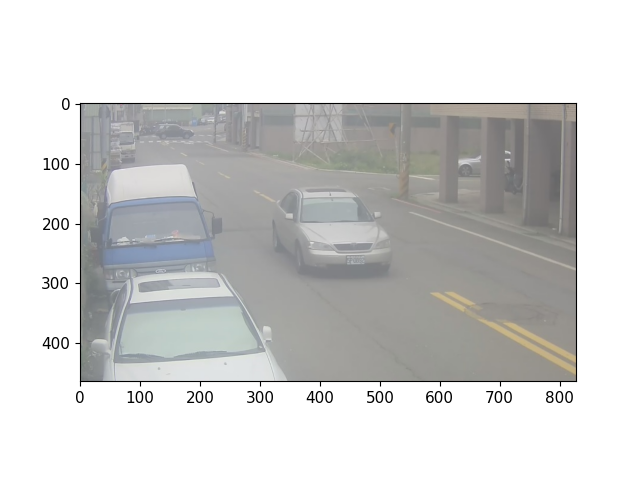

In [13]:
result_=results_all[0]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)







fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))



In [156]:
plt.savefig(filename_nameonly+'_original'+'.png', bbox_inches='tight', pad_inches=0)


In [ ]:
result_=results_all[0]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)







fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))



/data/licence_plate/_plate/weather/original/fog_05.jpg
fog_05


<IPython.core.display.Javascript object>


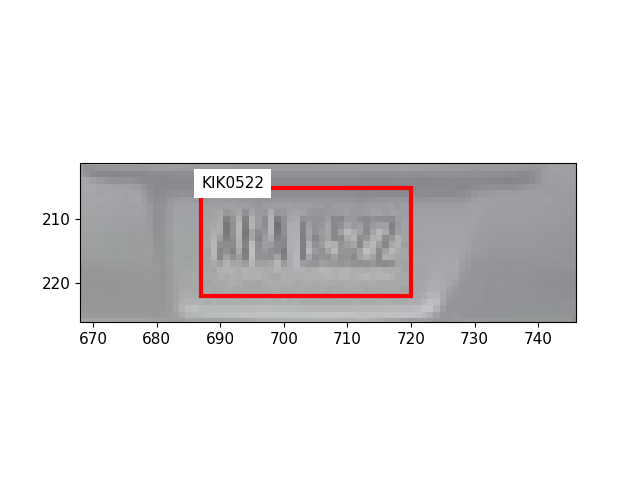

In [169]:
result_=results_all[0]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)







fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))
msg=np.array([[687, 205, 720, 222,1,34]])

for index_plate in range(msg.shape[0]):
    w=msg[index_plate,2]-msg[index_plate,0]
    h=msg[index_plate,3]-msg[index_plate,1]
    x=msg[index_plate,0]#-w/2
    y=msg[index_plate,1]#-h/2
    s='KIK0522'
    #print(x)
    #print(y)
    #print(w)
    #print(h)
    #print(s)

    rect = Rectangle((x, y), w, h, linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    #plt.text(x, y, s, bbox=dict(fill=False, edgecolor='red', linewidth=2))
    plt.text(x, y, s, bbox={'facecolor':'white', 'edgecolor':'none', 'pad':5})


/data/licence_plate/_plate/weather/original/fog_05.jpg
fog_05


<IPython.core.display.Javascript object>


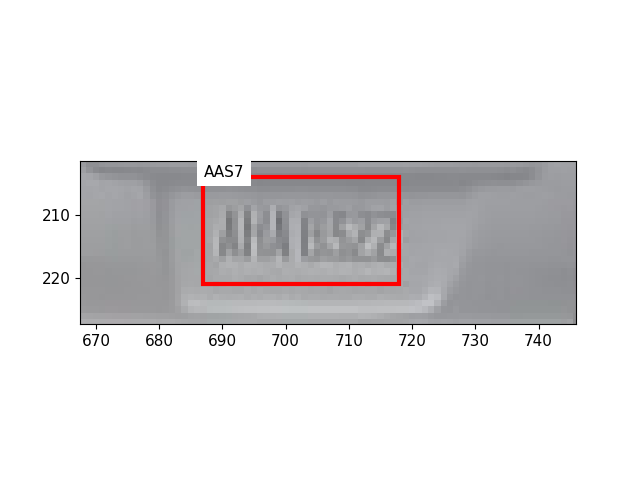

In [173]:
result_=results_all[0]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)







fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))
msg=np.array([[687, 204, 718, 221,1,34]])

for index_plate in range(msg.shape[0]):
    w=msg[index_plate,2]-msg[index_plate,0]
    h=msg[index_plate,3]-msg[index_plate,1]
    x=msg[index_plate,0]#-w/2
    y=msg[index_plate,1]#-h/2
    s='AAS7'
    #print(x)
    #print(y)
    #print(w)
    #print(h)
    #print(s)

    rect = Rectangle((x, y), w, h, linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    #plt.text(x, y, s, bbox=dict(fill=False, edgecolor='red', linewidth=2))
    plt.text(x, y, s, bbox={'facecolor':'white', 'edgecolor':'none', 'pad':5})


In [108]:
plt.savefig(filename_nameonly+'_yolov7'+'.png', bbox_inches='tight', pad_inches=0)


/data/licence_plate/_plate/weather/original/fog_01.jpg
fog_01


<IPython.core.display.Javascript object>


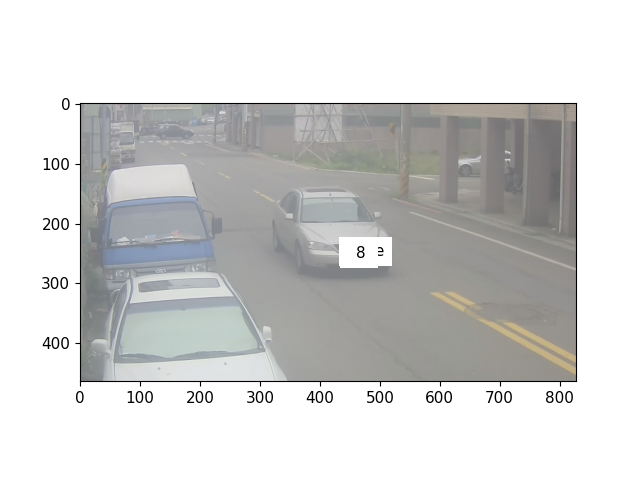

[[     444.12      253.79      475.16      269.38     0.96685          34]
 [      450.1      258.21      454.77      266.76     0.90701          23]
 [     445.61      258.45      450.45      266.92     0.89767           5]
 [      465.1      257.57      469.69      266.13     0.89613           9]
 [     469.86      257.59      474.11         266     0.87994           2]
 [     455.93         258      460.43      266.48     0.81897           0]
 [     460.46      257.76      465.04      266.37     0.67196           8]]
['445,253,475,270,5P0892']


In [14]:
result_=results_all[0]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)





fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))
print(result_[filename_nameonly])
print(label_data[filename_nameonly])
# Create a Rectangle patch


#print(msg.shape)
msg=result_[filename_nameonly]

for index_plate in range(msg.shape[0]):
    w=msg[index_plate,2]-msg[index_plate,0]
    h=msg[index_plate,3]-msg[index_plate,1]
    x=msg[index_plate,0]#-w/2
    y=msg[index_plate,1]#-h/2
    s=classes[int(msg[index_plate,5])]#-h/2
    #print(x)
    #print(y)
    #print(w)
    #print(h)
    #print(s)

    rect = Rectangle((x, y), w, h, linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    #plt.text(x, y, s, bbox=dict(fill=False, edgecolor='red', linewidth=2))
    plt.text(x, y, s, bbox={'facecolor':'white', 'edgecolor':'none', 'pad':5})

/data/licence_plate/_plate/weather/original/fog_05.jpg
fog_05


<IPython.core.display.Javascript object>


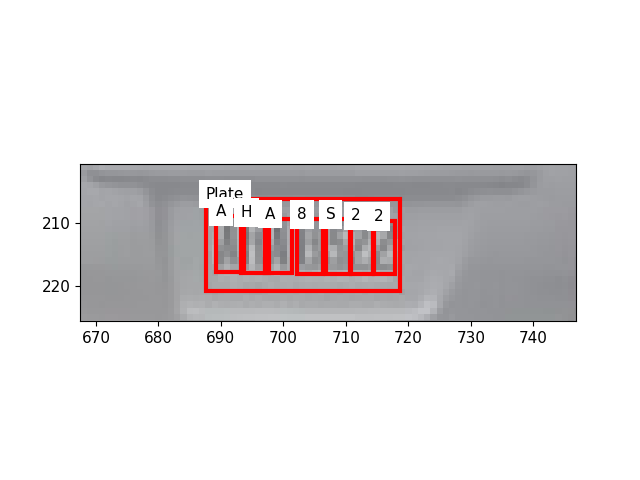

[[     687.54      206.03      718.68      220.76     0.96141          34]
 [     689.19      208.85      693.62      217.74     0.91704          10]
 [     697.04      209.24      701.33      217.94     0.88832          10]
 [     706.78      209.36      710.59      218.08     0.87752          26]
 [     710.79      209.53      714.39      218.03     0.87506           2]
 [     714.45      209.63      717.86      218.06     0.86082           2]
 [      702.2      209.32       706.4      218.11     0.85869           8]
 [     693.17      209.04      697.66      217.91     0.63391          17]
 [     123.43      278.91      141.96      288.13     0.63237          34]]
['688,207,719,220,AHA0322']


In [172]:
result_=results_all[1]
image_file = image_files[idx]
image = cv2.imread(image_file)
print(image_file)
filename_nameonly=image_file.split('/')[-1]
filename_nameonly=filename_nameonly.split('.')[0]
print(filename_nameonly)


#img, msg = image_generator.get_plate(bg_image=image)
#img, msg = image_generator.get_plate()

img = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (2048, 2048), interpolation=cv2.INTER_AREA)





fig, ax = plt.subplots()


ax.imshow(np.array(img,dtype=np.uint8))
print(result_[filename_nameonly])
print(label_data[filename_nameonly])
# Create a Rectangle patch


#print(msg.shape)
msg=result_[filename_nameonly]

for index_plate in range(msg.shape[0]):
    w=msg[index_plate,2]-msg[index_plate,0]
    h=msg[index_plate,3]-msg[index_plate,1]
    x=msg[index_plate,0]#-w/2
    y=msg[index_plate,1]#-h/2
    s=classes[int(msg[index_plate,5])]#-h/2
    #print(x)
    #print(y)
    #print(w)
    #print(h)
    #print(s)

    rect = Rectangle((x, y), w, h, linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    #plt.text(x, y, s, bbox=dict(fill=False, edgecolor='red', linewidth=2))
    plt.text(x, y, s, bbox={'facecolor':'white', 'edgecolor':'none', 'pad':5})


In [110]:
plt.savefig(filename_nameonly+'_ldyolov7'+'.png', bbox_inches='tight', pad_inches=0)


In [ ]:
plt.savefig('test.png', bbox_inches='tight', pad_inches=0)

## results = {}
print('conf_thres= '+str(conf_thres))


for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        ret, meta = run(img_p,conf_thres=conf_thres)
        #ret, meta = run_adaptive(img_p,label_data,conf_thres=conf_thres)
        #print(conf_thres)
        if ret[0] is not None:
            output = affine_transform(ret, meta) # output = [num_objs, 6(x1, y1, x2, y2, conf, cls)]
            results[bname] = output


In [10]:
#print(results)
for k, v in label_data.items():

    if k in results:
        r = group_plate(results[k]) # r = [{'plate': int[x1, y1, x2, y2], 'char':[int[x1, y1, x2, y2, label], ...]}, ...]
        if r==[]:
            print('plate is None')
        for plates in r:
            pred_str = [classes[x[-1]] for x in plates['char']]
            print('pred =%s'%pred_str)
            if plates['char']==[]:
                print('char is None')
        print('file %s, label = %s\n'%(k,v))


#pred_str = [classes[x[-1]] for x in obj['char']]


plate is None
file extra_000_0, label = ['100,80,200,160,235KRV']

plate is None
file extra_000_1, label = ['97,80,194,160,MCL9275']

plate is None
file extra_001_0, label = ['64,48,128,96,292U6']

plate is None
file extra_001_1, label = ['74,50,148,100,291U6']

plate is None
file extra_001_2, label = ['64,45,128,90,958BBB']

pred =['6', '6', '8', '8', '8']
file extra_002_0, label = ['124,57,248,114,958BBB']

plate is None
file extra_002_1, label = ['59,48,118,96,KCQ1019']

plate is None
file extra_002_2, label = ['76,53,152,106,235KRV']

plate is None
file extra_002_3, label = ['54,40,108,80,MCL9275']

pred =['A', 'K', 'L', '9', '5', '6', '6']
file extra_003_0, label = ['69,26,138,52,AKL9566']

plate is None
file extra_004_0, label = ['52,31,104,62,6395EB']

pred =['1', 'D', '1', '7', '4', '7']
file extra_005_0, label = ['0,68,106,136,101TAT']

pred =['J', '7', 'T', 'F', '8', '0', '1']
file extra_005_1, label = ['196,113,392,226,J7F801']

pred =['1', '0', '1', '7', 'A', '7', 'T']
file

In [18]:
import math

def compute_C(A, B, n):
    # 計算 C = e^((ln(B) - ln(A)) / n)
    C = math.exp((math.log(B) - math.log(A)) / n)
    return C

A=0.0001
B=1
n=99

C=compute_C(A,B,n)
for i in range(n+1):
    print('index=%d, value=%.05f.'%(i,A*math.pow(C, i )))

index=0, value=0.00010.
index=1, value=0.00011.
index=2, value=0.00012.
index=3, value=0.00013.
index=4, value=0.00015.
index=5, value=0.00016.
index=6, value=0.00017.
index=7, value=0.00019.
index=8, value=0.00021.
index=9, value=0.00023.
index=10, value=0.00025.
index=11, value=0.00028.
index=12, value=0.00031.
index=13, value=0.00034.
index=14, value=0.00037.
index=15, value=0.00040.
index=16, value=0.00044.
index=17, value=0.00049.
index=18, value=0.00053.
index=19, value=0.00059.
index=20, value=0.00064.
index=21, value=0.00071.
index=22, value=0.00077.
index=23, value=0.00085.
index=24, value=0.00093.
index=25, value=0.00102.
index=26, value=0.00112.
index=27, value=0.00123.
index=28, value=0.00135.
index=29, value=0.00148.
index=30, value=0.00163.
index=31, value=0.00179.
index=32, value=0.00196.
index=33, value=0.00215.
index=34, value=0.00236.
index=35, value=0.00260.
index=36, value=0.00285.
index=37, value=0.00313.
index=38, value=0.00343.
index=39, value=0.00376.
index=40, 

In [16]:
h_,w_ = view_dataset(label_data)
h_ = np.array(h_)
w_ = np.array(w_)

print(np.sort(h_))
print(np.mean(w_))


fog_01
['445,253,475,270,5P0892']
fog_02
['600,356,641,379,5P0892']
fog_03
['728,209,756,224,3780YK']
fog_04
['498,142,519,152,3780YK']
fog_05
['688,207,719,220,AHA0322']
fog_07
['379,162,402,172,RBR1168']
fog_08
['674,298,712,317,RBR1168']
fog_09
['431,188,454,199,063S2']
fog_10
['745,335,782,356,063S2']
fog_11
['282,163,301,174,2965W7']
fog_12
['587,373,629,395,2965W7']
fog_13
['752,210,777,220,T31709']
fog_14
['594,155,613,164,T3170']
fog_15
['591,153,608,162,T31709', '750,256,777,271,7706UC']
night_01
['196,136,244,157,ALF6322']
night_02
['85,3,114,16,ALF6322', '768,217,802,236,6527MY']
night_03
['394,34,418,48,6527MY']
night_04
['552,117,583,134,5379JU']
night_05
['412,300,466,328,5892FU']
night_06
['139,43,167,58,5892FU']
night_07
['299,361,357,382,LQ1463']
night_08
['562,183,598,197,ABJ2372']
night_09
['227,178,273,203,0830PJ', '374,76,404,88,ABJ2372']
night_10
['166,92,200,108,2101KP', '625,156,657,173,3990VW']
night_11
['246,64,283,81,AUG9117']
night_12
['611,128,645,145,ARN56

In [17]:
print(np.mean(h_))
print(np.mean(w_))

print(len(h_))
#for x_ in h_:
#    print(x_)

61.71551724137931
34.327586206896555
116


In [1]:

import cv2
# import hyperlpr3
import hyperlpr3 as lpr3

# Instantiate object
catcher = lpr3.LicensePlateCatcher()
# load image
#image = cv2.imread("images/test_img.jpg")

for f in tqdm(img_paths, ncols=80):
    if f.endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif')):
        bname = os.path.splitext(f)[0]
        img_p = img_dir + f
        image = cv2.imread(img_p)
        print(catcher(image))

# print result
#print(catcher(image))

NameError: name 'tqdm' is not defined